In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [37]:
df = pd.read_json("News_Category_Dataset_v3.json",lines=True)
df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


C:\Users\Aditi\AppData\Local\Temp\ipykernel_7812\2395369781.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='category', data=df, palette='viridis')


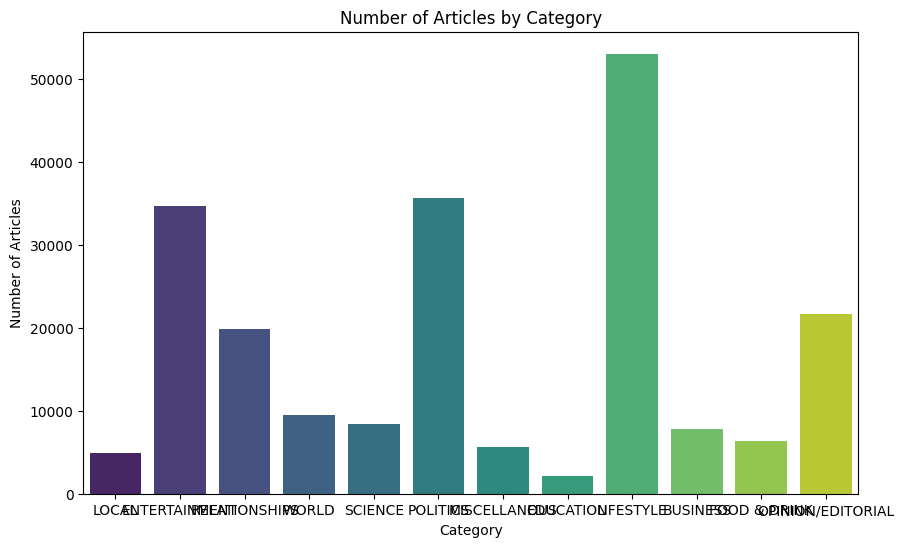

In [6]:
# Bar chart for number of articles by category
plt.figure(figsize=(10, 6))
sns.countplot(x='category', data=df, palette='viridis')
plt.title('Number of Articles by Category')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.show()

In [38]:
df['category'] = df['category'].replace({"HEALTHY LIVING": "WELLNESS",
"QUEER VOICES": "GROUPS VOICES",
"BUSINESS": "BUSINESS & FINANCES",
"PARENTS": "PARENTING",
"BLACK VOICES": "GROUPS VOICES",
"THE WORLDPOST": "WORLD NEWS",
"STYLE": "STYLE & BEAUTY",
"GREEN": "ENVIRONMENT",
"TASTE": "LIFESTYLE",
"WORLDPOST": "WORLD NEWS",
"SCIENCE": "SCIENCE & TECH",
"TECH": "SCIENCE & TECH",
"MONEY": "BUSINESS & FINANCES",
"ARTS": "ARTS & CULTURE",
"COLLEGE": "EDUCATION",
"LATINO VOICES": "GROUPS VOICES",
"CULTURE & ARTS": "ARTS & CULTURE",
"FIFTY": "MISCELLANEOUS",
"GOOD NEWS": "MISCELLANEOUS",
"TRAVEL":"LIFESTYLE"})

df['category'] = df['category'].replace({
    'WELLNESS':'LIFESTYLE',
    'STYLE & BEAUTY':'LIFESTYLE',
    'GROUPS VOICES':'OPINION/EDITORIAL',
    'WORLD NEWS': 'WORLD',
    'BUSINESS & FINANCES': 'BUSINESS',
    'COMEDY':'ENTERTAINMENT',
    'SPORTS':'ENTERTAINMENT',
    'HOME & LIVING':'LIFESTYLE',
    'PARENTING':'RELATIONSHIPS',
    'SCIENCE & TECH':'SCIENCE',
    'WEDDINGS':'RELATIONSHIPS',
    'ENVIRONMENT':'SCIENCE',
    'DIVORCE':'RELATIONSHIPS',
    'ARTS & CULTURE':'ENTERTAINMENT',
    'WOMEN':'OPINION/EDITORIAL',
    'IMPACT':'OPINION/EDITORIAL',
    'CRIME':'LOCAL',
    'MEDIA':'ENTERTAINMENT',
    'WEIRD NEWS':'MISCELLANOUS',
    'RELIGION':'OPINION/EDITORIAL',
    'U.S. NEWS':'LOCAL',
    'MISCELLANEOUS':'MISCELLANOUS'

})

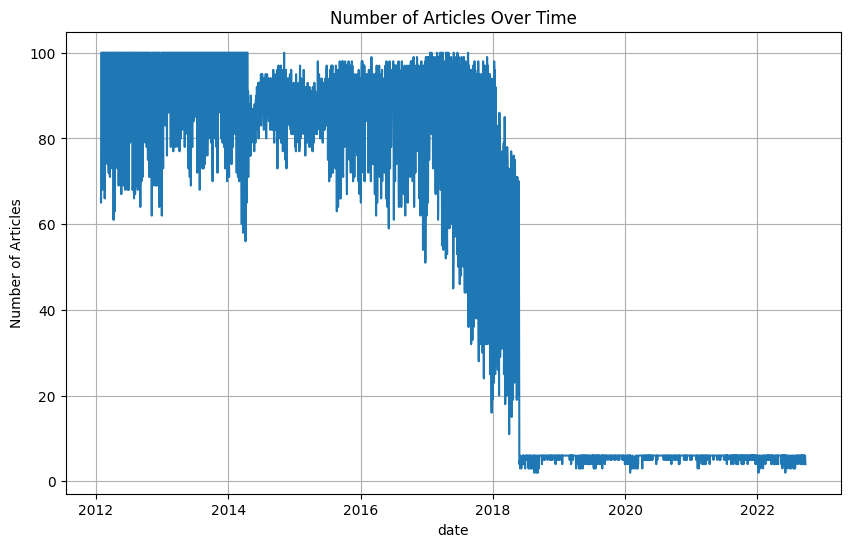

In [39]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Line chart for number of articles over time
articles_over_time = df.groupby(df['date'].dt.date).size()

plt.figure(figsize=(10, 6))
articles_over_time.plot(kind='line')
plt.title('Number of Articles Over Time')
plt.xlabel('date')
plt.ylabel('Number of Articles')
plt.grid(True)
plt.show()


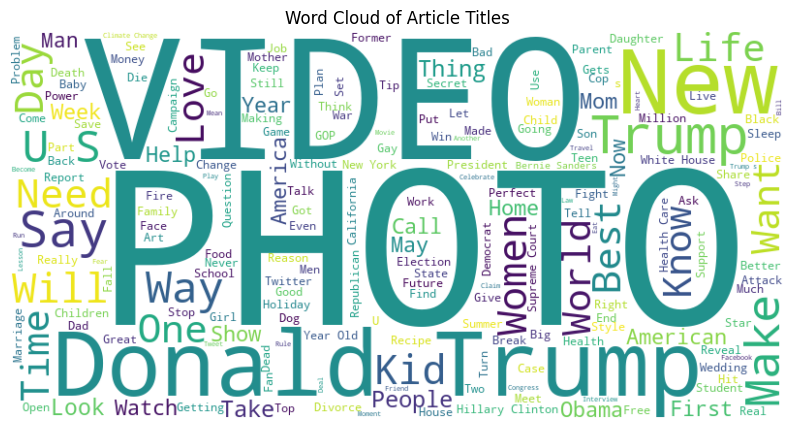

In [10]:
from wordcloud import WordCloud

# Combine all titles into a single string
text = ' '.join(df['headline'])

# Generate word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Article Titles')
plt.show()


In [52]:
# Randomly select half of the data
df_sampled = df.iloc[:200].sample(frac=1).reset_index(drop=True)


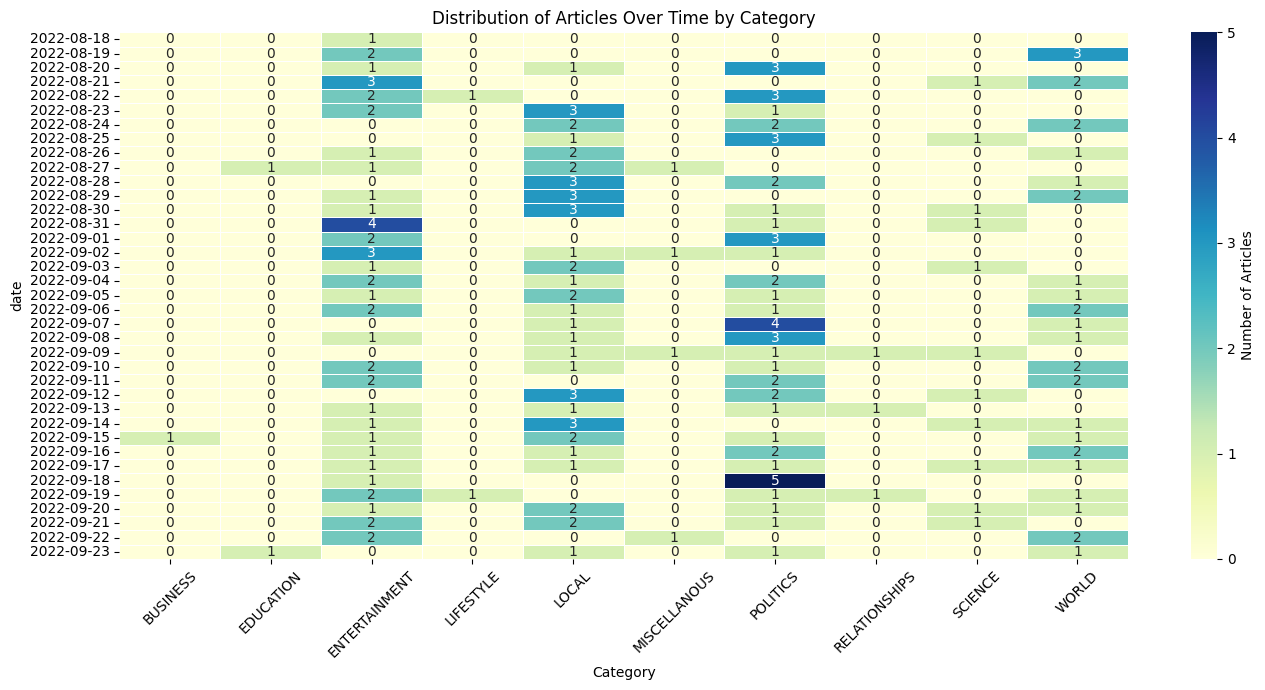

In [53]:

df_sampled['date'] = pd.to_datetime(df['date'])
heatmap_data = df_sampled.pivot_table(index=df_sampled['date'].dt.date, columns='category', aggfunc='size', fill_value=0)

all_dates = pd.date_range(start=df_sampled['date'].min(), end=df_sampled['date'].max()).date
heatmap_data = heatmap_data.reindex(all_dates, fill_value=0)

heatmap_data = heatmap_data.fillna(0)
# Improved Plotting of the Heatmap
plt.figure(figsize=(14, 7))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5, cbar_kws={'label': 'Number of Articles'})
plt.title('Distribution of Articles Over Time by Category')
plt.xlabel('Category')
plt.ylabel('date')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


